# Figure 1-1: Mesh with contact force arrow
This figure shows a mesh with an arrow representing the contact force.

In [36]:
import pyvista as pv

filepath = "meshes/Cuboid1_cg1.msh"

mesh = pv.read(filepath)

xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds

sphere = pv.Sphere(radius=0.001, center=(xmax, 0, 0.04))
arrow = pv.Arrow(start=(xmax + 0.01, 0, 0.04), direction=(-1, 0, 0), scale=0.01)

p = pv.Plotter(window_size=[1920, 1080])
p.add_mesh(
    mesh,
    show_edges=True,
    edge_color="black",
    color="gray",
    label="Mesh",
)
p.add_mesh(arrow, color="red", label="Load direction")
legend_entries = [
    ["Mesh", "gray", "triangle"],
    ["Contact force", "red", "line"],
]
p.add_legend(
    legend_entries,
    size=(0.3, 0.3),
    loc="lower right",
    border=False,
    font_family="arial",
)
p.camera.zoom(0.8)
p.show(screenshot="mesh_with_arrow.png")

Widget(value='<iframe src="http://localhost:46815/index.html?ui=P_0x722b1bcfda30_35&reconnect=auto" class="pyv…

# Figure 1-2: Graph representation of the problem configuration
This figure shows how the problem configuration of the mesh subject to contacts can be represented as a graph, with nodes representing the mesh vertices and edges representing the connections between them. We also visualize the contacts as virtual nodes connected to all mesh vertices, representing the influence of the contact forces on the mesh.

In [ ]:
from pathlib import Path

import numpy as np
import pyvista as pv

filepath = "meshes/Cuboid1_cg1.msh"
mesh = pv.read(filepath)

xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
virtual_pos = np.array([xmax + 0.005, 0.0, 0.04])

# Virtual node visual
virtual_node = pv.Sphere(radius=0.0008, center=virtual_pos)

# Vertex visuals
sphere = pv.Sphere(radius=0.0005)
vertices = mesh.glyph(scale=False, geom=sphere)

# Build one line segment from virtual node to each mesh vertex
all_points = np.vstack([virtual_pos, mesh.points])
line_cells = np.column_stack(
    [
        np.full(mesh.n_points, 2, dtype=np.int32),
        np.zeros(mesh.n_points, dtype=np.int32),
        np.arange(1, mesh.n_points + 1, dtype=np.int32),
    ]
).ravel()
virtual_edges = pv.PolyData()
virtual_edges.points = all_points
virtual_edges.lines = line_cells

output_path = Path("fig1.png")

p = pv.Plotter()
p.add_mesh(mesh.extract_all_edges(), color="gray", line_width=1)
p.add_mesh(virtual_edges, color="orange", line_width=0.5, opacity=0.5)
p.add_mesh(vertices, color="blue")
p.add_mesh(virtual_node, color="red")

# Use line faces for edge entries and circle faces for node entries in legend
legend_entries = [
    ["Mesh edges", "gray", "line"],
    ["Virtual edges", "orange", "line"],
    ["Mesh nodes", "blue", "circle"],
    ["Virtual node", "red", "circle"],
]
legend_actor = p.add_legend(
    legend_entries,
    size=(0.2, 0.2),
    loc="lower right",
    border=True,
)

# Robust legend text sizing via VTK actor
legend_text = legend_actor.GetEntryTextProperty()
legend_text.SetFontFamilyToArial()
legend_text.SetFontSize(24)

p.show(screenshot=str(output_path))
print(f"Saved figure to: {output_path}")

/home/bugart-lan/miniconda3/envs/meshnet/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:1802: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn(


Widget(value='<iframe src="http://localhost:46815/index.html?ui=P_0x722d7b290530_18&reconnect=auto" class="pyv…

Saved figure to: fig1.png


# Figure 1-3: Stress field prediction
This figure shows the predicted stress field within the mesh under the applied contact forces.

In [13]:
%load_ext autoreload
%autoreload 2

import meshio
import numpy as np
import torch

from graph_builder import GraphBuilderVirtual, GraphVisualizer
from nets import EncodeProcessDecode
from normalizer import Normalizer
from utils import msh_to_trimesh

filepath = "meshes/Cuboid1_cg1.msh"
mesh = meshio.read(filepath)

points = np.asarray(mesh.points)
xmin, ymin, zmin = points.min(axis=0)
xmax, ymax, zmax = points.max(axis=0)
bounds = (xmin, xmax, ymin, ymax, zmin, zmax)
print(
    f"bounds: ({xmin:.3f}, {xmax:.3f}, {ymin:.3f}, {ymax:.3f}, {zmin:.3f}, {zmax:.3f})"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

builder = GraphBuilderVirtual(std=0.01)
graph = builder.build(
    mesh, contacts=[(np.array([xmax, 0, 0.04]), np.array([-1, 0, 0]))]
)

checkpoint = torch.load("models/Model0.pth", map_location=device, weights_only=True)
params = checkpoint["params"]

normalizer = Normalizer(
    num_features=params["node_dim"],
    num_categorical=params["num_categorical"],
    device=device,
    stats=checkpoint["stats"],
)

model = EncodeProcessDecode(
    node_dim=params["node_dim"],
    edge_dim=params["edge_dim"],
    output_dim=params["output_dim"],
    latent_dim=params["latent_dim"],
    message_passing_steps=params["message_passing_steps"],
    use_layer_norm=params["use_layer_norm"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.no_grad():
    graph = graph.to(device)
    y_pred = normalizer.denormalize_y(model(normalizer.normalize(graph)))

graph.y = y_pred.detach().cpu()
graph = graph.to("cpu")

scalar_bar_args = {
    "title": "Pa\n",
    "title_font_size": 32,
    "label_font_size": 24,
    "font_family": "arial",
    "vertical": True,
    "position_x": 0.84,
    "position_y": 0.1,
    "width": 0.08,
    "height": 0.8,
    "fmt": "%.f",
    "n_labels": 5,
}
visualizer = GraphVisualizer(msh_to_trimesh(mesh))
visualizer.stress(
    graph,
    clim=[0, 1e4],
    show_contacts=False,
    save_path="fig2.png",
    scalar_bar_args=scalar_bar_args,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

bounds: (-0.015, 0.015, -0.015, 0.015, 0.000, 0.050)


Widget(value='<iframe src="http://localhost:46815/index.html?ui=P_0x722b40324440_12&reconnect=auto" class="pyv…

# Figure 2: Data processing

Saved plot to: fig2_data_processing.png


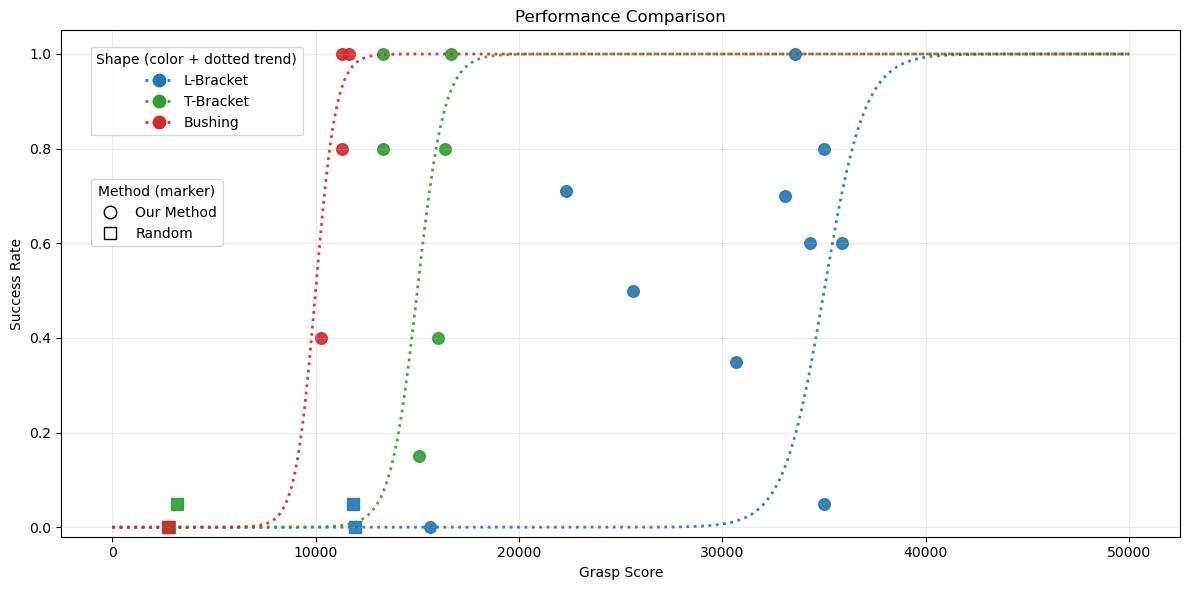

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

data = {
    "L-Bracket": {
        "Our Method": {
            "Success rate": [0.5, 0.71, 0, 0.8, 0.6, 0.35, 0.05, 0.6, 1.0, 0.7],
            "Score": [
                25611,
                22329,
                15619,
                34980,
                34304,
                30689,
                34980,
                35880,
                33582,
                33079,
            ],
        },
        "Random": {
            "Success rate": [0.05, 0.0],
            "Score": [11853, 11952],
        },
    },
    "T-Bracket": {
        "Our Method": {
            "Success rate": [0.8, 1.0, 0.15, 0.8, 1, 0.4],
            "Score": [13309, 13303, 15089, 16370, 16675, 16001],
        },
        "Random": {
            "Success rate": [0.05, 0.0],
            "Score": [3194, 2777],
        },
    },
    "Bushing": {
        "Our Method": {
            "Success rate": [0.4, 0.8, 1.0, 1.0],
            "Score": [10247, 11305, 11643, 11308],
        },
        "Random": {
            "Success rate": [0.0],
            "Score": [2760],
        },
    },
}

# Color encodes shape family
shape_colors = {
    "L-Bracket": "tab:blue",
    "T-Bracket": "tab:green",
    "Bushing": "tab:red",
}

# Marker encodes sampling method
method_markers = {
    "Our Method": "o",
    "Random": "s",
}


def sigmoid(x, k, x0):
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))


x = np.linspace(0.0, 50000, 10000)
trends = {
    "L-Bracket": sigmoid(x, k=0.001, x0=35000),
    "T-Bracket": sigmoid(x, k=0.0015, x0=15000),
    "Bushing": sigmoid(x, k=0.002, x0=10000),
}


fig, ax = plt.subplots(figsize=(12, 6))

for shape_name, shape_data in data.items():
    # Plot points by method, sharing shape color
    for method_name, method_data in shape_data.items():
        ax.scatter(
            method_data["Score"],
            method_data["Success rate"],
            c=shape_colors[shape_name],
            marker=method_markers[method_name],
            s=70,
            alpha=0.9,
        )

    ax.plot(
        x,
        trends[shape_name],
        linestyle=":",
        linewidth=2.0,
        color=shape_colors[shape_name],
        alpha=0.9,
    )

# Legend 1: color -> shape
shape_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle=":",
        color=color,
        markerfacecolor=color,
        markeredgecolor=color,
        markersize=9,
        linewidth=2,
        label=shape,
    )
    for shape, color in shape_colors.items()
]

# Legend 2: marker -> method
method_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label=method,
    )
    for method, marker in method_markers.items()
]

legend_shapes = ax.legend(
    handles=shape_handles,
    title="Shape (color + dotted trend)",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
)
ax.add_artist(legend_shapes)
ax.legend(
    handles=method_handles,
    title="Method (marker)",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.72),
)

ax.set_xlabel("Grasp Score")
ax.set_ylabel("Success Rate")
ax.set_title("Performance Comparison")
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.25)
plt.tight_layout()

output_path = Path("fig2_data_processing.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {output_path}")

plt.show()